# 03c — Short Peptide Structural Preparation and Guided Docking

## Obiettivo

Questo notebook prende i frammenti prioritari selezionati nel notebook **02d** e li tratta come complessi receptor–peptide indipendenti.

Il notebook:

1. carica il ranking prodotto dal 02d;
2. costruisce un pannello rappresentativo di frammenti corti;
3. include, oltre ai frammenti raccomandati, il miglior riferimento da 15 aa;
4. verifica e normalizza i file PDB receptor–peptide;
5. prepara gli input per **Rosetta FlexPepDock refinement**;
6. esegue opzionalmente Rosetta;
7. raccoglie gli score di tutte le pose;
8. seleziona la migliore posa per ciascun frammento;
9. riallinea il recettore e calcola l'RMSD del peptide;
10. misura ritenzione dei contatti nativi, contatti degli hotspot e clash;
11. produce un ranking di docking guidato.

## Posizione nella pipeline

```text
01 / 01b → 02b → 02c → 02d → 03c
```

## Domanda scientifica

Il notebook 02d valutava i frammenti mantenuti nella posa cristallografica originale.

Il 03c affronta la domanda successiva:

> Dopo un refinement strutturale come peptide indipendente, il frammento conserva una posa compatibile con l'interfaccia B–D?

## Limite

`-pep_refine` parte da una posa iniziale già vicina a quella nativa.  
Non rappresenta un docking completamente cieco e non dimostra l'affinità sperimentale.


## 1. Dipendenze

```bash
pip install pandas numpy matplotlib biopython
```

È inoltre richiesto Rosetta con il programma `FlexPepDocking`.


In [1]:
from pathlib import Path
from collections import defaultdict
import json
import math
import os
import re
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from Bio.PDB import (
        PDBParser,
        PDBIO,
        Select,
        Superimposer,
        NeighborSearch,
        is_aa,
    )
except ImportError as exc:
    raise ImportError(
        "Biopython non è installato. Eseguire: pip install biopython"
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 160)

print("Ambiente inizializzato correttamente.")

Ambiente inizializzato correttamente.


## 2. Configurazione

`ROSETTA_NSTRUCT = 2` mantiene l'esecuzione iniziale relativamente leggera.

Per una valutazione finale più affidabile sarà opportuno aumentare successivamente il numero di pose, per esempio a 20–100.


In [2]:
RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

CONTACT_CUTOFF_A = 4.5
CLASH_CUTOFF_A = 2.0

# Pannello di docking
INCLUDE_BEST_15AA_REFERENCE = True
MAX_DOCKING_FRAGMENTS = 6

# Rosetta
RUN_ROSETTA_FLEXPEPDOCK = True
ROSETTA_NSTRUCT = 2

ROSETTA_FLEXPEPDOCK_EXECUTABLE = Path(
    "/Users/robertobruzzese/Downloads/"
    "rosetta.binary.m1.release-408/main/source/build/src/release/"
    "macos/12.7/64/arm/clang/14.0/static/"
    "FlexPepDocking.static.macosclangrelease"
)

ROSETTA_DATABASE = Path(
    "/Users/robertobruzzese/Downloads/"
    "rosetta.binary.m1.release-408/main/database"
)

OUTPUT_DIR = Path("outputs")
RANKING_02D_DIR = OUTPUT_DIR / "short_peptide_structural_ranking"
RANKING_02D_CSV = (
    RANKING_02D_DIR / "short_peptide_structural_energetic_ranking.csv"
)
RECOMMENDED_02D_CSV = (
    RANKING_02D_DIR / "recommended_fragments_for_next_stage.csv"
)
NATIVE_COMPLEX_DIR = (
    RANKING_02D_DIR / "native_fragment_complexes"
)

DOCKING_DIR = OUTPUT_DIR / "short_peptide_guided_docking_03c"
INPUT_DIR = DOCKING_DIR / "inputs"
ROSETTA_DIR = DOCKING_DIR / "rosetta_flexpepdock"
ROSETTA_INPUT_DIR = ROSETTA_DIR / "inputs"
ROSETTA_OUTPUT_DIR = ROSETTA_DIR / "outputs"
BEST_POSE_DIR = DOCKING_DIR / "best_poses"

for directory in [
    DOCKING_DIR,
    INPUT_DIR,
    ROSETTA_DIR,
    ROSETTA_INPUT_DIR,
    ROSETTA_OUTPUT_DIR,
    BEST_POSE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Input ranking 02d:", RANKING_02D_CSV.resolve())
print("Output 03c:", DOCKING_DIR.resolve())

Input ranking 02d: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/short_peptide_structural_energetic_ranking.csv
Output 03c: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c


## 3. Caricamento del ranking 02d


In [3]:
if not RANKING_02D_CSV.exists():
    raise FileNotFoundError(
        f"File mancante: {RANKING_02D_CSV}\n"
        "Eseguire prima il notebook 02d nella stessa cartella di lavoro."
    )

ranking_02d = pd.read_csv(RANKING_02D_CSV)

required_columns = {
    "fragment_id",
    "sequence",
    "start_resseq",
    "end_resseq",
    "length",
    "n_hotspots",
    "hotspot_positions",
    "final_priority_score",
    "complex_pdb",
}

missing = required_columns - set(ranking_02d.columns)
if missing:
    raise ValueError(
        "Il ranking 02d non contiene le colonne: "
        + ", ".join(sorted(missing))
    )

for col in ["start_resseq", "end_resseq", "length", "n_hotspots"]:
    ranking_02d[col] = pd.to_numeric(
        ranking_02d[col], errors="raise"
    ).astype(int)

ranking_02d["final_priority_score"] = pd.to_numeric(
    ranking_02d["final_priority_score"],
    errors="coerce",
)

if "recommended_for_next_stage" in ranking_02d.columns:
    ranking_02d["recommended_for_next_stage"] = (
        ranking_02d["recommended_for_next_stage"]
        .astype(str)
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
        .astype(bool)
    )
else:
    ranking_02d["recommended_for_next_stage"] = False

print("Frammenti nel ranking 02d:", len(ranking_02d))
display(
    ranking_02d[
        [
            "structural_rank" if "structural_rank" in ranking_02d.columns else "fragment_id",
            "fragment_id",
            "sequence",
            "length",
            "n_hotspots",
            "final_priority_score",
            "recommended_for_next_stage",
        ]
    ].head(20)
)

Frammenti nel ranking 02d: 15


,structural_rank,fragment_id,sequence,length,n_hotspots,final_priority_score,recommended_for_next_stage
0,1,F0001,YIGERCQYRDLKW,13,7,0.733518,True
1,2,F0010,IGERCQYRDLK,11,6,0.674343,True
2,3,F0009,GERCQYRDL,9,6,0.670994,True
3,4,F0017,RCQYRDL,7,5,0.663598,True
4,5,F0011,GERCQYRDLKW,11,6,0.644423,True
5,6,F0018,ERCQYRDLK,9,5,0.595192,False
6,7,F0005,GYIGERCQYRDLKWW,15,7,0.537836,False
7,8,F0008,YIGERCQYR,9,6,0.535857,False
8,9,F0002,VGYIGERCQYRDL,13,7,0.506430,False
9,10,F0029,IGERCQY,7,4,0.436792,False


## 4. Costruzione del pannello di docking

Il pannello contiene:

- i frammenti marcati come raccomandati dal 02d;
- il miglior frammento da 15 residui, se non è già incluso;
- al massimo sei sistemi.

Questo consente di confrontare una serie rappresentativa:

```text
15 aa → 13 aa → 11 aa → 9 aa → 7 aa
```


In [4]:
recommended = ranking_02d[
    ranking_02d["recommended_for_next_stage"]
].copy()

if recommended.empty:
    recommended = ranking_02d.sort_values(
        "final_priority_score",
        ascending=False,
    ).head(5).copy()

panel_parts = [recommended]

if INCLUDE_BEST_15AA_REFERENCE:
    best_15aa = (
        ranking_02d[ranking_02d["length"] == 15]
        .sort_values(
            [
                "foldx_interaction_energy_kcal_mol"
                if "foldx_interaction_energy_kcal_mol" in ranking_02d.columns
                else "final_priority_score",
                "final_priority_score",
            ],
            ascending=[
                True
                if "foldx_interaction_energy_kcal_mol" in ranking_02d.columns
                else False,
                False,
            ],
        )
        .head(1)
    )

    if not best_15aa.empty:
        panel_parts.append(best_15aa)

docking_panel = (
    pd.concat(panel_parts, ignore_index=True)
    .sort_values(
        ["length", "final_priority_score"],
        ascending=[False, False],
    )
    .drop_duplicates("fragment_id")
    .head(MAX_DOCKING_FRAGMENTS)
    .reset_index(drop=True)
)

docking_panel.insert(
    0,
    "docking_order",
    np.arange(1, len(docking_panel) + 1),
)

docking_panel["panel_role"] = np.where(
    docking_panel["length"] == 15,
    "long_reference",
    "recommended_short_fragment",
)

print("Frammenti nel pannello:", len(docking_panel))
display(
    docking_panel[
        [
            "docking_order",
            "fragment_id",
            "sequence",
            "start_resseq",
            "end_resseq",
            "length",
            "n_hotspots",
            "final_priority_score",
            "panel_role",
        ]
    ]
)

Frammenti nel pannello: 6


,docking_order,fragment_id,sequence,start_resseq,end_resseq,length,n_hotspots,final_priority_score,panel_role
0,1,F0005,GYIGERCQYRDLKWW,36,50,15,7,0.537836,long_reference
1,2,F0001,YIGERCQYRDLKW,37,49,13,7,0.733518,recommended_short_fragment
2,3,F0010,IGERCQYRDLK,38,48,11,6,0.674343,recommended_short_fragment
3,4,F0011,GERCQYRDLKW,39,49,11,6,0.644423,recommended_short_fragment
4,5,F0009,GERCQYRDL,39,47,9,6,0.670994,recommended_short_fragment
5,6,F0017,RCQYRDL,41,47,7,5,0.663598,recommended_short_fragment


## 5. Risoluzione dei file PDB nativi

Il notebook usa i complessi già estratti dal 02d.

Se il percorso memorizzato nel CSV non è più valido, ricerca automaticamente il file nella cartella:

```text
outputs/short_peptide_structural_ranking/native_fragment_complexes/
```


In [5]:
def resolve_native_complex(row):
    stored = Path(str(row["complex_pdb"])).expanduser()

    candidates = [
        stored,
        Path.cwd() / stored,
    ]

    candidates.extend(
        sorted(NATIVE_COMPLEX_DIR.glob(f"{row['fragment_id']}_*.pdb"))
    )

    for path in candidates:
        if path.exists():
            return path.resolve()

    raise FileNotFoundError(
        f"Complesso PDB non trovato per {row['fragment_id']}. "
        f"Cercato anche in {NATIVE_COMPLEX_DIR}."
    )


docking_panel["native_complex_pdb"] = docking_panel.apply(
    resolve_native_complex,
    axis=1,
)

for row in docking_panel.itertuples(index=False):
    print(row.fragment_id, "→", row.native_complex_pdb)

F0005 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0005_BD_D36-50.pdb
F0001 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0001_BD_D37-49.pdb
F0010 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0010_BD_D38-48.pdb
F0011 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0011_BD_D39-49.pdb
F0009 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0009_BD_D39-47.pdb
F0017 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0017_BD_D41-47.pdb


## 6. Controllo e normalizzazione dei complessi PDB

Ogni complesso deve contenere:

- catena B come recettore;
- catena D come peptide;
- la sequenza prevista;
- esattamente il numero di residui previsto.

Il notebook salva una copia normalizzata nella cartella `inputs/`.


In [6]:
parser = PDBParser(QUIET=True)

AA3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


def standard_residues(chain):
    return [
        residue for residue in chain
        if is_aa(residue, standard=True)
    ]


def sequence_from_chain(chain):
    return "".join(
        AA3_TO_1.get(res.get_resname().upper(), "X")
        for res in standard_residues(chain)
    )


class ProteinChainsOnly(Select):
    def accept_residue(self, residue):
        return int(is_aa(residue, standard=True))


validation_rows = []
normalized_paths = {}

for row in docking_panel.itertuples(index=False):
    source_path = Path(row.native_complex_pdb)
    structure = parser.get_structure(row.fragment_id, str(source_path))
    model = next(structure.get_models())

    chain_ids = [chain.id for chain in model]
    if RECEPTOR_CHAIN not in chain_ids or PEPTIDE_CHAIN not in chain_ids:
        raise ValueError(
            f"{row.fragment_id}: catene richieste B e D non presenti. "
            f"Catene trovate: {chain_ids}"
        )

    receptor_residues = standard_residues(model[RECEPTOR_CHAIN])
    peptide_residues = standard_residues(model[PEPTIDE_CHAIN])
    observed_sequence = sequence_from_chain(model[PEPTIDE_CHAIN])

    if observed_sequence != row.sequence:
        raise ValueError(
            f"{row.fragment_id}: sequenza PDB {observed_sequence} "
            f"diversa da quella attesa {row.sequence}."
        )

    if len(peptide_residues) != int(row.length):
        raise ValueError(
            f"{row.fragment_id}: {len(peptide_residues)} residui PDB "
            f"ma lunghezza attesa {row.length}."
        )

    normalized_path = INPUT_DIR / f"{row.fragment_id}_native_complex.pdb"
    io = PDBIO()
    io.set_structure(structure)
    io.save(str(normalized_path), select=ProteinChainsOnly())
    normalized_paths[row.fragment_id] = normalized_path

    validation_rows.append({
        "fragment_id": row.fragment_id,
        "source_pdb": str(source_path),
        "normalized_pdb": str(normalized_path),
        "chains": ",".join(chain_ids),
        "n_receptor_residues": len(receptor_residues),
        "n_peptide_residues": len(peptide_residues),
        "expected_sequence": row.sequence,
        "observed_sequence": observed_sequence,
        "sequence_match": observed_sequence == row.sequence,
    })

input_validation = pd.DataFrame(validation_rows)
display(input_validation)

if not input_validation["sequence_match"].all():
    raise AssertionError("Almeno una sequenza non coincide con il ranking 02d.")

print("Tutti i complessi sono validi.")

,fragment_id,source_pdb,normalized_pdb,chains,n_receptor_residues,n_peptide_residues,expected_sequence,observed_sequence,sequence_match
0,F0005,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0005_BD_D36-50.pdb,outputs/short_peptide_guided_docking_03c/inputs/F0005_native_complex.pdb,"B,D",614,15,GYIGERCQYRDLKWW,GYIGERCQYRDLKWW,True
1,F0001,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0001_BD_D37-49.pdb,outputs/short_peptide_guided_docking_03c/inputs/F0001_native_complex.pdb,"B,D",614,13,YIGERCQYRDLKW,YIGERCQYRDLKW,True
2,F0010,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0010_BD_D38-48.pdb,outputs/short_peptide_guided_docking_03c/inputs/F0010_native_complex.pdb,"B,D",614,11,IGERCQYRDLK,IGERCQYRDLK,True
3,F0011,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0011_BD_D39-49.pdb,outputs/short_peptide_guided_docking_03c/inputs/F0011_native_complex.pdb,"B,D",614,11,GERCQYRDLKW,GERCQYRDLKW,True
4,F0009,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0009_BD_D39-47.pdb,outputs/short_peptide_guided_docking_03c/inputs/F0009_native_complex.pdb,"B,D",614,9,GERCQYRDL,GERCQYRDL,True
5,F0017,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0017_BD_D41-47.pdb,outputs/short_peptide_guided_docking_03c/inputs/F0017_native_complex.pdb,"B,D",614,7,RCQYRDL,RCQYRDL,True


Tutti i complessi sono validi.


## 7. Analisi strutturale iniziale

Vengono registrati i contatti nativi che costituiranno il riferimento per valutare le pose Rosetta.


In [7]:
def heavy_atoms(residues):
    atoms = []
    for residue in residues:
        for atom in residue.get_atoms():
            element = (atom.element or "").strip().upper()
            if element != "H":
                atoms.append(atom)
    return atoms


def residue_key(residue, chain_id):
    _, resseq, icode = residue.id
    return (chain_id, int(resseq), str(icode).strip())


def interchain_metrics(structure_path):
    structure = parser.get_structure(
        Path(structure_path).stem,
        str(structure_path),
    )
    model = next(structure.get_models())

    receptor_residues = standard_residues(model[RECEPTOR_CHAIN])
    peptide_residues = standard_residues(model[PEPTIDE_CHAIN])

    receptor_atoms = heavy_atoms(receptor_residues)
    peptide_atoms = heavy_atoms(peptide_residues)
    search = NeighborSearch(receptor_atoms)

    atom_contacts = 0
    residue_pairs = set()
    peptide_contact_residues = set()
    clashes = 0
    min_distance = float("inf")

    for pep_atom in peptide_atoms:
        neighbors = search.search(
            pep_atom.coord,
            CONTACT_CUTOFF_A,
            level="A",
        )

        for rec_atom in neighbors:
            distance = float(
                np.linalg.norm(pep_atom.coord - rec_atom.coord)
            )
            min_distance = min(min_distance, distance)
            atom_contacts += 1

            rec_res = rec_atom.get_parent()
            pep_res = pep_atom.get_parent()

            pair = (
                residue_key(rec_res, RECEPTOR_CHAIN),
                residue_key(pep_res, PEPTIDE_CHAIN),
            )
            residue_pairs.add(pair)
            peptide_contact_residues.add(pair[1])

            if distance < CLASH_CUTOFF_A:
                clashes += 1

    if math.isinf(min_distance):
        for pep_atom in peptide_atoms:
            for rec_atom in receptor_atoms:
                distance = float(
                    np.linalg.norm(pep_atom.coord - rec_atom.coord)
                )
                min_distance = min(min_distance, distance)

    return {
        "n_atom_contacts": atom_contacts,
        "n_residue_contacts": len(residue_pairs),
        "n_peptide_contact_residues": len(peptide_contact_residues),
        "peptide_contact_fraction": (
            len(peptide_contact_residues) / len(peptide_residues)
            if peptide_residues else np.nan
        ),
        "min_interchain_distance_A": min_distance,
        "n_atom_clashes_lt_2A": clashes,
        "residue_pairs": residue_pairs,
    }


native_metrics_map = {}
native_rows = []

for row in docking_panel.itertuples(index=False):
    path = normalized_paths[row.fragment_id]
    metrics = interchain_metrics(path)
    native_metrics_map[row.fragment_id] = metrics

    native_rows.append({
        "fragment_id": row.fragment_id,
        "native_atom_contacts": metrics["n_atom_contacts"],
        "native_residue_contacts": metrics["n_residue_contacts"],
        "native_peptide_contact_residues": metrics[
            "n_peptide_contact_residues"
        ],
        "native_peptide_contact_fraction": metrics[
            "peptide_contact_fraction"
        ],
        "native_min_interchain_distance_A": metrics[
            "min_interchain_distance_A"
        ],
        "native_atom_clashes_lt_2A": metrics[
            "n_atom_clashes_lt_2A"
        ],
    })

native_metrics_df = pd.DataFrame(native_rows)
display(native_metrics_df)

,fragment_id,native_atom_contacts,native_residue_contacts,native_peptide_contact_residues,native_peptide_contact_fraction,native_min_interchain_distance_A,native_atom_clashes_lt_2A
0,F0005,224,42,13,0.866667,2.602119,0
1,F0001,223,41,12,0.923077,2.602119,0
2,F0010,185,37,10,0.909091,2.602119,0
3,F0011,212,36,10,0.909091,2.602119,0
4,F0009,160,31,8,0.888889,2.602119,0
5,F0017,117,25,6,0.857143,2.602119,0


## 8. Preparazione degli input Rosetta

I file normalizzati vengono copiati nella cartella di lavoro di FlexPepDock.


In [8]:
rosetta_input_rows = []

for row in docking_panel.itertuples(index=False):
    source = normalized_paths[row.fragment_id]
    target = ROSETTA_INPUT_DIR / f"{row.fragment_id}.pdb"
    shutil.copy2(source, target)

    rosetta_input_rows.append({
        "fragment_id": row.fragment_id,
        "sequence": row.sequence,
        "length": row.length,
        "rosetta_input": str(target),
    })

rosetta_inputs = pd.DataFrame(rosetta_input_rows)
display(rosetta_inputs)

,fragment_id,sequence,length,rosetta_input
0,F0005,GYIGERCQYRDLKWW,15,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0005.pdb
1,F0001,YIGERCQYRDLKW,13,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0001.pdb
2,F0010,IGERCQYRDLK,11,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb
3,F0011,GERCQYRDLKW,11,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0011.pdb
4,F0009,GERCQYRDL,9,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0009.pdb
5,F0017,RCQYRDL,7,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0017.pdb


## 9. Individuazione di Rosetta


In [9]:
def resolve_executable(configured_path, executable_names):
    if configured_path:
        configured = Path(configured_path).expanduser()
        if configured.exists() and os.access(configured, os.X_OK):
            return str(configured.resolve())

    for name in executable_names:
        found = shutil.which(name)
        if found:
            return str(Path(found).resolve())

    return None


rosetta_bin = resolve_executable(
    ROSETTA_FLEXPEPDOCK_EXECUTABLE,
    [
        "FlexPepDocking.default.linuxgccrelease",
        "FlexPepDocking.static.linuxgccrelease",
        "FlexPepDocking.default.macosclangrelease",
        "FlexPepDocking.static.macosclangrelease",
    ],
)

rosetta_db = (
    Path(ROSETTA_DATABASE).expanduser()
    if ROSETTA_DATABASE
    else None
)

print("Detected Rosetta:", rosetta_bin)
print("Rosetta database:", rosetta_db)
print("RUN_ROSETTA_FLEXPEPDOCK:", RUN_ROSETTA_FLEXPEPDOCK)
print("ROSETTA_NSTRUCT:", ROSETTA_NSTRUCT)

Detected Rosetta: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease
Rosetta database: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/database
RUN_ROSETTA_FLEXPEPDOCK: True
ROSETTA_NSTRUCT: 2


## 10. Generazione dello script FlexPepDock

Viene utilizzato il protocollo:

```text
-pep_refine -ex1 -ex2aro -use_input_sc
```

Ogni frammento ha una cartella di output distinta.


In [10]:
rosetta_script = ROSETTA_DIR / "run_flexpepdock_refinement.sh"

lines = [
    "#!/usr/bin/env bash",
    "set -euo pipefail",
    'SCRIPT_DIR="$(cd "$(dirname "${BASH_SOURCE[0]}")" && pwd)"',
    'cd "$SCRIPT_DIR"',
    'ROSETTA_BIN="${ROSETTA_BIN:-FlexPepDocking.default.linuxgccrelease}"',
    'ROSETTA_DB="${ROSETTA_DB:-}"',
    'if [[ -z "$ROSETTA_DB" ]]; then',
    '  echo "ROSETTA_DB is not set" >&2',
    '  exit 1',
    'fi',
    "mkdir -p outputs",
    "",
]

for row in rosetta_inputs.itertuples(index=False):
    input_name = Path(row.rosetta_input).name
    outdir = f"outputs/{row.fragment_id}"

    lines.extend([
        f'mkdir -p "{outdir}"',
        (
            f'"$ROSETTA_BIN" -database "$ROSETTA_DB" '
            f'-s "inputs/{input_name}" '
            f'-pep_refine -ex1 -ex2aro -use_input_sc '
            f'-nstruct {ROSETTA_NSTRUCT} '
            f'-out:path:pdb "{outdir}" '
            f'-out:path:score "{outdir}" '
            f'-out:file:scorefile "{row.fragment_id}_refinement.sc" '
            f'> "{outdir}/{row.fragment_id}.log" 2>&1'
        ),
        "",
    ])

rosetta_script.write_text(
    "\n".join(lines) + "\n",
    encoding="utf-8",
)
rosetta_script.chmod(0o755)

print("Script generato:", rosetta_script.resolve())
print()
print(rosetta_script.read_text(encoding="utf-8"))

Script generato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/run_flexpepdock_refinement.sh

#!/usr/bin/env bash
set -euo pipefail
SCRIPT_DIR="$(cd "$(dirname "${BASH_SOURCE[0]}")" && pwd)"
cd "$SCRIPT_DIR"
ROSETTA_BIN="${ROSETTA_BIN:-FlexPepDocking.default.linuxgccrelease}"
ROSETTA_DB="${ROSETTA_DB:-}"
if [[ -z "$ROSETTA_DB" ]]; then
  echo "ROSETTA_DB is not set" >&2
  exit 1
fi
mkdir -p outputs

mkdir -p "outputs/F0005"
"$ROSETTA_BIN" -database "$ROSETTA_DB" -s "inputs/F0005.pdb" -pep_refine -ex1 -ex2aro -use_input_sc -nstruct 2 -out:path:pdb "outputs/F0005" -out:path:score "outputs/F0005" -out:file:scorefile "F0005_refinement.sc" > "outputs/F0005/F0005.log" 2>&1

mkdir -p "outputs/F0001"
"$ROSETTA_BIN" -database "$ROSETTA_DB" -s "inputs/F0001.pdb" -pep_refine -ex1 -ex2aro -use_input_sc -nstruct 2 -out:path:pdb "outputs/F0001" -out:path:score "outputs/F0001" -out:file:scorefile "F0001_refinement.sc" > "outputs/F0001/F0001.log" 2>&1

## 11. Esecuzione opzionale di Rosetta

Se Rosetta non viene trovato, il notebook non perde la preparazione svolta: lo script può essere eseguito manualmente dal terminale.


In [11]:
rosetta_execution = {
    "executed": False,
    "returncode": None,
    "stdout": "",
    "stderr": "",
}

if RUN_ROSETTA_FLEXPEPDOCK:
    if rosetta_bin is None:
        raise FileNotFoundError(
            "Rosetta FlexPepDock non trovato. "
            "Configurare ROSETTA_FLEXPEPDOCK_EXECUTABLE."
        )

    if rosetta_db is None or not rosetta_db.exists():
        raise FileNotFoundError(
            "Database Rosetta non trovato. "
            "Configurare ROSETTA_DATABASE."
        )

    env = os.environ.copy()
    env["ROSETTA_BIN"] = rosetta_bin
    env["ROSETTA_DB"] = str(rosetta_db.resolve())

    result = subprocess.run(
        ["bash", rosetta_script.name],
        cwd=str(ROSETTA_DIR),
        env=env,
        capture_output=True,
        text=True,
        check=False,
    )

    rosetta_execution = {
        "executed": True,
        "returncode": int(result.returncode),
        "stdout": result.stdout,
        "stderr": result.stderr,
    }

    if result.stdout:
        print(result.stdout)

    if result.stderr:
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            "Rosetta FlexPepDock è terminato con errore. "
            "Controllare i log nelle cartelle di output."
        )

    print("Rosetta FlexPepDock completato.")
else:
    print(
        "Rosetta non eseguito automaticamente.\n"
        "Script disponibile in:",
        rosetta_script.resolve(),
    )

Rosetta FlexPepDock completato.


## 12. Verifica degli output Rosetta


In [12]:
output_status_rows = []

for row in docking_panel.itertuples(index=False):
    outdir = ROSETTA_OUTPUT_DIR / row.fragment_id
    scorefiles = sorted(outdir.glob("*.sc"))
    pdb_files = sorted(outdir.glob("*.pdb"))
    log_files = sorted(outdir.glob("*.log"))

    output_status_rows.append({
        "fragment_id": row.fragment_id,
        "output_directory": str(outdir),
        "n_scorefiles": len(scorefiles),
        "n_pdb_poses": len(pdb_files),
        "n_logs": len(log_files),
        "expected_nstruct": ROSETTA_NSTRUCT,
        "output_complete": (
            len(scorefiles) >= 1
            and len(pdb_files) >= ROSETTA_NSTRUCT
        ),
    })

rosetta_output_status = pd.DataFrame(output_status_rows)
display(rosetta_output_status)

if RUN_ROSETTA_FLEXPEPDOCK:
    incomplete = rosetta_output_status[
        ~rosetta_output_status["output_complete"]
    ]
    if not incomplete.empty:
        warnings.warn(
            "Alcuni output Rosetta sembrano incompleti. "
            "Controllare i log."
        )

,fragment_id,output_directory,n_scorefiles,n_pdb_poses,n_logs,expected_nstruct,output_complete
0,F0005,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0005,1,2,1,2,True
1,F0001,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0001,1,2,1,2,True
2,F0010,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0010,1,2,1,2,True
3,F0011,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0011,1,2,1,2,True
4,F0009,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0009,1,2,1,2,True
5,F0017,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0017,1,2,1,2,True


## 13. Parsing degli score Rosetta

Per il ranking viene preferita, nell'ordine:

1. `reweighted_sc`;
2. `I_sc`;
3. `total_score`;
4. `score`.

Un valore più basso è considerato più favorevole.


In [13]:
def parse_rosetta_scorefile(path):
    lines = [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8",
            errors="ignore",
        ).splitlines()
        if line.startswith("SCORE:")
    ]

    if len(lines) < 2:
        return pd.DataFrame()

    header = lines[0].split()[1:]
    records = []

    for line in lines[1:]:
        values = line.split()[1:]
        if len(values) == len(header):
            records.append(dict(zip(header, values)))

    df = pd.DataFrame(records)

    for column in df.columns:
        if column != "description":
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce",
            )

    return df


score_frames = []

for scorefile in sorted(ROSETTA_OUTPUT_DIR.glob("*/*.sc")):
    df = parse_rosetta_scorefile(scorefile)

    if not df.empty:
        df.insert(0, "fragment_id", scorefile.parent.name)
        df.insert(1, "scorefile", str(scorefile))
        score_frames.append(df)

rosetta_scores = (
    pd.concat(score_frames, ignore_index=True)
    if score_frames
    else pd.DataFrame()
)

if rosetta_scores.empty:
    print("Nessun file di score Rosetta trovato.")
else:
    print("Pose Rosetta con score:", len(rosetta_scores))
    display(rosetta_scores.head(20))

Pose Rosetta con score: 12


,fragment_id,scorefile,total_score,I_bsa,I_hb,I_pack,I_sc,I_unsat,dslf_fa13,fa_atr,fa_dun,fa_elec,fa_intra_rep,fa_intra_sol_xover4,fa_rep,fa_sol,hbond_bb_sc,hbond_lr_bb,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pep_sc,pep_sc_noref,pro_close,rama_prepro,ref,reweighted_sc,rmsALL,rmsALL_CAPRI_if,rmsALL_allIF,rmsALL_if,rmsBB,rmsBB_CAPRI_if,rmsBB_allIF,rmsBB_if,rmsCA,rmsCA_if,rmsSC_CAPRI_if,rmsSC_allIF,startRMSall,startRMSallif,startRMSbb,startRMSca,yhh_planarity,description
0,F0001,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0001/F0001_refinement.sc,150.146,1762.193,6.0,-0.040,-41.934,8.0,20.062,-3336.631,1098.202,-630.683,7.273,127.295,750.846,2056.961,-80.281,-116.935,-42.648,-61.121,-89.341,31.667,-85.174,-11.108,-15.327,15.396,247.681,236.359,97.104,2.219,1.523,1.469,2.238,1.229,0.722,0.731,1.314,1.237,1.315,1.896,1.798,0.0,0.0,0.0,0.0,1.217,F0001_0001
1,F0001,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0001/F0001_refinement.sc,137.108,1761.389,7.0,-0.045,-47.736,6.0,19.927,-3339.583,1108.779,-646.971,7.195,127.301,750.345,2063.509,-83.751,-115.397,-49.472,-60.469,-90.160,30.985,-85.273,-13.772,-17.991,15.146,246.991,236.359,75.599,2.163,1.636,1.736,2.264,0.944,0.531,0.519,0.972,0.997,1.034,2.141,2.268,0.0,0.0,0.0,0.0,1.645,F0001_0002
2,F0005,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0005/F0005_refinement.sc,103.239,1911.014,10.0,-0.010,-54.132,6.0,19.950,-3349.516,1098.689,-663.599,7.076,127.502,740.696,2081.199,-89.072,-118.359,-53.884,-62.005,-88.881,32.492,-85.399,-23.447,-30.725,17.560,247.921,239.419,25.660,2.674,1.783,1.759,2.840,0.827,0.480,0.477,0.869,0.843,0.865,2.230,2.161,0.0,0.0,0.0,0.0,1.451,F0005_0001
3,F0005,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0005/F0005_refinement.sc,104.964,1867.611,9.0,0.004,-49.566,4.0,19.935,-3341.747,1088.450,-652.712,7.070,128.003,740.971,2068.295,-87.624,-118.501,-49.041,-61.839,-91.614,31.715,-85.767,-19.519,-26.797,20.684,248.146,239.419,35.879,2.739,1.871,1.850,2.909,0.863,0.517,0.524,0.925,0.869,0.927,2.347,2.280,0.0,0.0,0.0,0.0,1.122,F0005_0002
4,F0009,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0009/F0009_refinement.sc,110.615,1339.836,3.0,-0.001,-34.659,9.0,21.724,-3289.471,1084.881,-637.010,7.029,125.988,710.045,2036.563,-83.793,-114.588,-41.648,-58.875,-91.915,31.014,-83.281,-4.485,-4.271,13.238,248.045,231.927,71.472,3.897,2.299,2.299,4.149,2.566,1.392,1.418,2.779,2.705,2.951,2.828,2.819,0.0,0.0,0.0,0.0,0.743,F0009_0001
5,F0009,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0009/F0009_refinement.sc,119.136,1300.340,5.0,-0.021,-36.099,7.0,21.709,-3288.744,1084.338,-628.692,7.069,125.557,720.694,2028.481,-81.765,-114.588,-48.835,-60.205,-90.508,29.830,-82.994,-1.277,-1.063,15.162,249.664,231.927,81.759,3.108,1.888,1.829,3.067,2.792,1.410,1.454,2.807,2.841,2.872,2.193,2.051,0.0,0.0,0.0,0.0,1.034,F0009_0002
6,F0010,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0010/F0010_refinement.sc,141.083,1602.379,5.0,-0.018,-38.422,8.0,21.718,-3303.897,1092.026,-639.576,7.279,125.799,736.413,2052.099,-82.264,-116.725,-45.697,-60.549,-89.426,29.409,-84.703,-4.461,-5.836,17.466,247.093,233.516,98.200,2.812,1.751,1.703,2.874,1.665,0.848,0.874,1.681,1.736,1.770,2.263,2.155,0.0,0.0,0.0,0.0,1.103,F0010_0001
7,F0010,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0010/F0010_refinement.sc,93.967,1663.684,7.0,0.015,-51.989,5.0,21.704,-3306.343,1087.551,-647.912,7.050,125.989,713.295,2050.291,-85.139,-116.915,-47.248,-59.712,-89.824,29.833,-85.075,-12.060,-13.435,15.193,246.559,233.516,29.918,1.394,0.962,0.886,1.392,1.090,0.537,0.558,1.107,1.101,1.106,1.199,1.057,0.0,0.0,0.0,0.0,1.153,F0010_0002
8,F0011,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0011/F0011_refinement.sc,165.206,1557.309,3.0,-0.029,-34.863,6.0,21.875,-3298.669,1092.497,-615.985,7.190,126.978,732.402,

## 14. Selezione della migliore posa per frammento


In [14]:
best_rosetta_rows = []

if not rosetta_scores.empty:
    ranking_column = next(
        (
            column
            for column in [
                "reweighted_sc",
                "I_sc",
                "total_score",
                "score",
            ]
            if column in rosetta_scores.columns
        ),
        None,
    )

    if ranking_column is None:
        raise ValueError(
            "Nessuna colonna Rosetta utilizzabile per il ranking."
        )

    for fragment_id, group in rosetta_scores.groupby("fragment_id"):
        valid_group = group.dropna(subset=[ranking_column]).copy()

        if valid_group.empty:
            continue

        best = valid_group.sort_values(
            ranking_column,
            ascending=True,
        ).iloc[0]

        description = str(best.get("description", ""))
        pose_path = (
            ROSETTA_OUTPUT_DIR
            / fragment_id
            / f"{description}.pdb"
        )

        record = best.to_dict()
        record["rosetta_ranking_column"] = ranking_column
        record["best_pose_pdb"] = (
            str(pose_path) if pose_path.exists() else ""
        )
        best_rosetta_rows.append(record)

best_rosetta_poses = pd.DataFrame(best_rosetta_rows)

if not best_rosetta_poses.empty:
    display(
        best_rosetta_poses[
            [
                column
                for column in [
                    "fragment_id",
                    "rosetta_ranking_column",
                    "reweighted_sc",
                    "I_sc",
                    "total_score",
                    "description",
                    "best_pose_pdb",
                ]
                if column in best_rosetta_poses.columns
            ]
        ]
    )
else:
    print("Nessuna migliore posa disponibile.")

,fragment_id,rosetta_ranking_column,reweighted_sc,I_sc,total_score,description,best_pose_pdb
0,F0001,reweighted_sc,75.599,-47.736,137.108,F0001_0002,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0001/F0001_0002.pdb
1,F0005,reweighted_sc,25.660,-54.132,103.239,F0005_0001,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0005/F0005_0001.pdb
2,F0009,reweighted_sc,71.472,-34.659,110.615,F0009_0001,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0009/F0009_0001.pdb
3,F0010,reweighted_sc,29.918,-51.989,93.967,F0010_0002,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0010/F0010_0002.pdb
4,F0011,reweighted_sc,78.826,-47.144,132.488,F0011_0002,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0011/F0011_0002.pdb
5,F0017,reweighted_sc,101.971,-36.802,140.600,F0017_0002,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0017/F0017_0002.pdb


## 15. RMSD del peptide dopo allineamento sul recettore

Procedura:

1. allineamento degli atomi Cα della catena B della posa Rosetta sul complesso nativo;
2. applicazione della trasformazione a tutta la posa;
3. RMSD degli atomi Cα del peptide D.

In questo modo si misura lo spostamento del peptide rispetto al recettore.


In [15]:
def ca_atoms_by_residue(chain):
    atoms = {}

    for residue in standard_residues(chain):
        if "CA" not in residue:
            continue

        key = (
            int(residue.id[1]),
            str(residue.id[2]).strip(),
        )
        atoms[key] = residue["CA"]

    return atoms


def align_pose_to_native_receptor(native_path, pose_path):
    native_structure = parser.get_structure(
        "native",
        str(native_path),
    )
    pose_structure = parser.get_structure(
        "pose",
        str(pose_path),
    )

    native_model = next(native_structure.get_models())
    pose_model = next(pose_structure.get_models())

    native_rec = ca_atoms_by_residue(
        native_model[RECEPTOR_CHAIN]
    )
    pose_rec = ca_atoms_by_residue(
        pose_model[RECEPTOR_CHAIN]
    )

    common_rec_keys = sorted(
        set(native_rec) & set(pose_rec)
    )

    if len(common_rec_keys) < 3:
        raise ValueError(
            "Atomi Cα del recettore insufficienti per l'allineamento."
        )

    fixed_atoms = [
        native_rec[key] for key in common_rec_keys
    ]
    moving_atoms = [
        pose_rec[key] for key in common_rec_keys
    ]

    superimposer = Superimposer()
    superimposer.set_atoms(fixed_atoms, moving_atoms)
    superimposer.apply(
        list(pose_structure.get_atoms())
    )

    native_pep = ca_atoms_by_residue(
        native_model[PEPTIDE_CHAIN]
    )
    pose_pep = ca_atoms_by_residue(
        pose_model[PEPTIDE_CHAIN]
    )

    common_pep_keys = sorted(
        set(native_pep) & set(pose_pep)
    )

    if not common_pep_keys:
        raise ValueError(
            "Nessun residuo peptidico comune per il calcolo RMSD."
        )

    squared_distances = []

    for key in common_pep_keys:
        diff = (
            native_pep[key].coord
            - pose_pep[key].coord
        )
        squared_distances.append(
            float(np.dot(diff, diff))
        )

    peptide_rmsd = math.sqrt(
        float(np.mean(squared_distances))
    )

    return (
        pose_structure,
        float(superimposer.rms),
        peptide_rmsd,
        len(common_rec_keys),
        len(common_pep_keys),
    )

## 16. Valutazione delle migliori pose

Per ciascuna posa vengono calcolati:

- RMSD del recettore dopo allineamento;
- RMSD Cα del peptide;
- ritenzione dei contatti nativi;
- precisione dei contatti della posa;
- ritenzione dei residui peptidici coinvolti nell'interfaccia;
- numero di clash atomici.


In [16]:
pose_evaluation_rows = []

for row in best_rosetta_poses.itertuples(index=False):
    fragment_id = row.fragment_id
    pose_path = Path(row.best_pose_pdb)

    if not pose_path.exists():
        warnings.warn(
            f"Posa PDB non trovata per {fragment_id}: {pose_path}"
        )
        continue

    native_path = normalized_paths[fragment_id]

    (
        aligned_pose_structure,
        receptor_alignment_rmsd,
        peptide_ca_rmsd,
        n_receptor_ca,
        n_peptide_ca,
    ) = align_pose_to_native_receptor(
        native_path,
        pose_path,
    )

    aligned_path = (
        BEST_POSE_DIR
        / f"{fragment_id}_best_aligned_to_native_receptor.pdb"
    )

    io = PDBIO()
    io.set_structure(aligned_pose_structure)
    io.save(str(aligned_path))

    pose_metrics = interchain_metrics(aligned_path)
    native_metrics = native_metrics_map[fragment_id]

    native_pairs = native_metrics["residue_pairs"]
    pose_pairs = pose_metrics["residue_pairs"]
    common_pairs = native_pairs & pose_pairs

    native_contact_recall = (
        len(common_pairs) / len(native_pairs)
        if native_pairs else np.nan
    )

    pose_contact_precision = (
        len(common_pairs) / len(pose_pairs)
        if pose_pairs else np.nan
    )

    pose_evaluation_rows.append({
        "fragment_id": fragment_id,
        "best_pose_pdb_original": str(pose_path),
        "best_pose_pdb_aligned": str(aligned_path),
        "receptor_CA_alignment_RMSD_A": receptor_alignment_rmsd,
        "peptide_CA_RMSD_after_receptor_alignment_A": peptide_ca_rmsd,
        "n_receptor_CA_aligned": n_receptor_ca,
        "n_peptide_CA_compared": n_peptide_ca,
        "pose_atom_contacts": pose_metrics["n_atom_contacts"],
        "pose_residue_contacts": pose_metrics[
            "n_residue_contacts"
        ],
        "pose_peptide_contact_residues": pose_metrics[
            "n_peptide_contact_residues"
        ],
        "pose_peptide_contact_fraction": pose_metrics[
            "peptide_contact_fraction"
        ],
        "native_contact_recall": native_contact_recall,
        "pose_contact_precision": pose_contact_precision,
        "pose_min_interchain_distance_A": pose_metrics[
            "min_interchain_distance_A"
        ],
        "pose_atom_clashes_lt_2A": pose_metrics[
            "n_atom_clashes_lt_2A"
        ],
    })

pose_evaluation = pd.DataFrame(pose_evaluation_rows)

if not pose_evaluation.empty:
    display(pose_evaluation)
else:
    print("Nessuna posa valutata.")

,fragment_id,best_pose_pdb_original,best_pose_pdb_aligned,receptor_CA_alignment_RMSD_A,peptide_CA_RMSD_after_receptor_alignment_A,n_receptor_CA_aligned,n_peptide_CA_compared,pose_atom_contacts,pose_residue_contacts,pose_peptide_contact_residues,pose_peptide_contact_fraction,native_contact_recall,pose_contact_precision,pose_min_interchain_distance_A,pose_atom_clashes_lt_2A
0,F0001,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0001/F0001_0002.pdb,outputs/short_peptide_guided_docking_03c/best_poses/F0001_best_aligned_to_native_receptor.pdb,1.490028e-14,0.996883,614,13,225,40,13,1.000000,0.804878,0.825000,2.554578,0
1,F0005,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0005/F0005_0001.pdb,outputs/short_peptide_guided_docking_03c/best_poses/F0005_best_aligned_to_native_receptor.pdb,1.490028e-14,0.843274,614,15,245,54,14,0.933333,0.976190,0.759259,2.558475,0
2,F0009,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0009/F0009_0001.pdb,outputs/short_peptide_guided_docking_03c/best_poses/F0009_best_aligned_to_native_receptor.pdb,1.490028e-14,2.705444,614,9,170,31,8,0.888889,0.645161,0.645161,2.795179,0
3,F0010,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0010/F0010_0002.pdb,outputs/short_peptide_guided_docking_03c/best_poses/F0010_best_aligned_to_native_receptor.pdb,1.490028e-14,1.100980,614,11,223,40,10,0.909091,0.972973,0.900000,2.489856,0
4,F0011,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0011/F0011_0002.pdb,outputs/short_peptide_guided_docking_03c/best_poses/F0011_best_aligned_to_native_receptor.pdb,1.490028e-14,1.242429,614,11,237,37,10,0.909091,0.833333,0.810811,2.599493,0
5,F0017,outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/outputs/F0017/F0017_0002.pdb,outputs/short_peptide_guided_docking_03c/best_poses/F0017_best_aligned_to_native_receptor.pdb,1.490028e-14,2.018940,614,7,159,29,7,1.000000,0.840000,0.724138,2.612956,0


## 17. Conservazione dei contatti degli hotspot

La metrica considera soltanto i residui peptidici identificati come hotspot nel 02b/02c.

Per ogni frammento si misura la quota degli hotspot che mantengono almeno un contatto con la catena B dopo il refinement.


In [17]:
def parse_hotspot_resseqs(text):
    if pd.isna(text):
        return set()

    values = set()

    for token in str(text).split(";"):
        match = re.search(r"(\d+)", token)
        if match:
            values.add(int(match.group(1)))

    return values


def peptide_contact_resseqs(residue_pairs):
    return {
        int(peptide_key[1])
        for _, peptide_key in residue_pairs
    }


hotspot_rows = []

for row in docking_panel.itertuples(index=False):
    fragment_id = row.fragment_id
    hotspots = parse_hotspot_resseqs(row.hotspot_positions)

    native_contacting = peptide_contact_resseqs(
        native_metrics_map[fragment_id]["residue_pairs"]
    )

    native_hotspot_contacting = hotspots & native_contacting

    pose_row = pose_evaluation[
        pose_evaluation["fragment_id"] == fragment_id
    ]

    if pose_row.empty:
        hotspot_rows.append({
            "fragment_id": fragment_id,
            "n_hotspots": len(hotspots),
            "native_hotspots_in_contact": len(
                native_hotspot_contacting
            ),
            "pose_hotspots_in_contact": np.nan,
            "hotspot_contact_preservation": np.nan,
        })
        continue

    aligned_path = Path(
        pose_row.iloc[0]["best_pose_pdb_aligned"]
    )
    pose_metrics = interchain_metrics(aligned_path)
    pose_contacting = peptide_contact_resseqs(
        pose_metrics["residue_pairs"]
    )
    pose_hotspot_contacting = hotspots & pose_contacting

    preservation = (
        len(
            pose_hotspot_contacting
            & native_hotspot_contacting
        )
        / len(native_hotspot_contacting)
        if native_hotspot_contacting
        else np.nan
    )

    hotspot_rows.append({
        "fragment_id": fragment_id,
        "n_hotspots": len(hotspots),
        "native_hotspots_in_contact": len(
            native_hotspot_contacting
        ),
        "pose_hotspots_in_contact": len(
            pose_hotspot_contacting
        ),
        "hotspot_contact_preservation": preservation,
        "native_contacting_hotspot_resseqs": ";".join(
            map(str, sorted(native_hotspot_contacting))
        ),
        "pose_contacting_hotspot_resseqs": ";".join(
            map(str, sorted(pose_hotspot_contacting))
        ),
    })

hotspot_contact_metrics = pd.DataFrame(hotspot_rows)
display(hotspot_contact_metrics)

,fragment_id,n_hotspots,native_hotspots_in_contact,pose_hotspots_in_contact,hotspot_contact_preservation,native_contacting_hotspot_resseqs,pose_contacting_hotspot_resseqs
0,F0005,7,7,7,1.0,37;39;41;43;44;45;47,37;39;41;43;44;45;47
1,F0001,7,7,7,1.0,37;39;41;43;44;45;47,37;39;41;43;44;45;47
2,F0010,6,6,6,1.0,39;41;43;44;45;47,39;41;43;44;45;47
3,F0011,6,6,6,1.0,39;41;43;44;45;47,39;41;43;44;45;47
4,F0009,6,6,6,1.0,39;41;43;44;45;47,39;41;43;44;45;47
5,F0017,5,5,5,1.0,41;43;44;45;47,41;43;44;45;47


## 18. Ranking integrato del docking guidato

Il ranking combina:

- score Rosetta;
- ritenzione dei contatti nativi;
- conservazione dei contatti degli hotspot;
- frazione del peptide ancora in contatto;
- RMSD del peptide;
- penalità per clash.

Un punteggio alto indica una priorità computazionale maggiore.


In [18]:
analysis = docking_panel.merge(
    native_metrics_df,
    on="fragment_id",
    how="left",
)

if not best_rosetta_poses.empty:
    keep_score_columns = [
        column
        for column in [
            "fragment_id",
            "reweighted_sc",
            "I_sc",
            "total_score",
            "score",
            "description",
            "rosetta_ranking_column",
            "best_pose_pdb",
        ]
        if column in best_rosetta_poses.columns
    ]

    analysis = analysis.merge(
        best_rosetta_poses[keep_score_columns],
        on="fragment_id",
        how="left",
    )

analysis = analysis.merge(
    pose_evaluation,
    on="fragment_id",
    how="left",
)

analysis = analysis.merge(
    hotspot_contact_metrics,
    on="fragment_id",
    how="left",
    suffixes=("", "_hotspot"),
)


def minmax(series, higher_is_better=True):
    values = pd.to_numeric(series, errors="coerce")
    valid = values.dropna()

    if valid.empty:
        return pd.Series(0.0, index=values.index)

    if valid.max() == valid.min():
        result = pd.Series(0.5, index=values.index)
        result[values.isna()] = 0.0
        return result

    result = (
        values - valid.min()
    ) / (
        valid.max() - valid.min()
    )

    if not higher_is_better:
        result = 1.0 - result

    result[values.isna()] = 0.0
    return result


rosetta_score_column = next(
    (
        column
        for column in [
            "reweighted_sc",
            "I_sc",
            "total_score",
            "score",
        ]
        if column in analysis.columns
    ),
    None,
)

if rosetta_score_column:
    analysis["norm_rosetta_score"] = minmax(
        analysis[rosetta_score_column],
        higher_is_better=False,
    )
else:
    analysis["norm_rosetta_score"] = 0.0

analysis["norm_native_contact_recall"] = minmax(
    analysis["native_contact_recall"]
)
analysis["norm_hotspot_preservation"] = minmax(
    analysis["hotspot_contact_preservation"]
)
analysis["norm_pose_contact_fraction"] = minmax(
    analysis["pose_peptide_contact_fraction"]
)
analysis["norm_low_peptide_rmsd"] = minmax(
    analysis[
        "peptide_CA_RMSD_after_receptor_alignment_A"
    ],
    higher_is_better=False,
)
analysis["clash_penalty"] = np.where(
    analysis["pose_atom_clashes_lt_2A"].fillna(0) > 0,
    1.0,
    0.0,
)

analysis["guided_docking_combined_score"] = (
    0.28 * analysis["norm_rosetta_score"]
    + 0.26 * analysis["norm_native_contact_recall"]
    + 0.20 * analysis["norm_hotspot_preservation"]
    + 0.14 * analysis["norm_pose_contact_fraction"]
    + 0.12 * analysis["norm_low_peptide_rmsd"]
    - 0.50 * analysis["clash_penalty"]
)

analysis = (
    analysis
    .sort_values(
        [
            "guided_docking_combined_score",
            "native_contact_recall",
            "hotspot_contact_preservation",
        ],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

analysis.insert(
    0,
    "guided_docking_rank",
    np.arange(1, len(analysis) + 1),
)

analysis["recommended_after_guided_docking"] = (
    (analysis["guided_docking_rank"] <= 3)
    & (analysis["pose_atom_clashes_lt_2A"].fillna(0) == 0)
)

display(
    analysis[
        [
            column
            for column in [
                "guided_docking_rank",
                "fragment_id",
                "sequence",
                "length",
                rosetta_score_column,
                "native_contact_recall",
                "pose_contact_precision",
                "hotspot_contact_preservation",
                "pose_peptide_contact_fraction",
                "peptide_CA_RMSD_after_receptor_alignment_A",
                "pose_atom_clashes_lt_2A",
                "guided_docking_combined_score",
                "recommended_after_guided_docking",
            ]
            if column is not None and column in analysis.columns
        ]
    ]
)

,guided_docking_rank,fragment_id,sequence,length,reweighted_sc,native_contact_recall,pose_contact_precision,hotspot_contact_preservation,pose_peptide_contact_fraction,peptide_CA_RMSD_after_receptor_alignment_A,pose_atom_clashes_lt_2A,guided_docking_combined_score,recommended_after_guided_docking
0,1,F0005,GYIGERCQYRDLKWW,15,25.660,0.976190,0.759259,1.0,0.933333,0.843274,0,0.816000,True
1,2,F0010,IGERCQYRDLK,11,29.918,0.972973,0.900000,1.0,0.909091,1.100980,0,0.750697,True
2,3,F0001,YIGERCQYRDLKW,13,75.599,0.804878,0.825000,1.0,1.000000,0.996883,0,0.572312,True
3,4,F0011,GERCQYRDLKW,11,78.826,0.833333,0.810811,1.0,0.909091,1.242429,0,0.452452,False
4,5,F0017,RCQYRDL,7,101.971,0.840000,0.724138,1.0,1.000000,2.018940,0,0.437271,False
5,6,F0009,GERCQYRDL,9,71.472,0.645161,0.645161,1.0,0.888889,2.705444,0,0.211907,False


## 19. Grafici


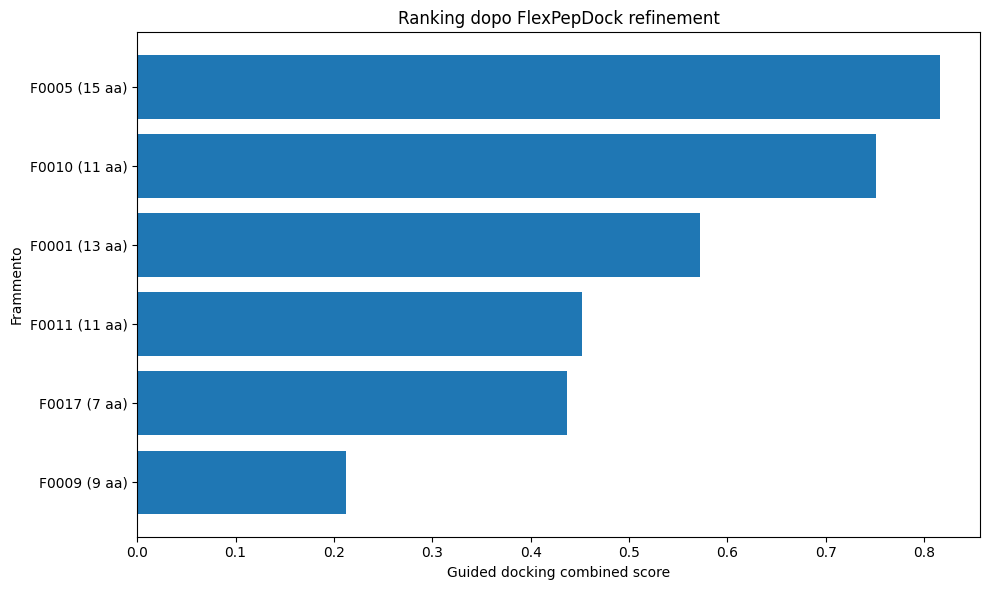

In [19]:
plot_df = analysis.sort_values(
    "guided_docking_combined_score",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["fragment_id"]
    + " ("
    + plot_df["length"].astype(str)
    + " aa)",
    plot_df["guided_docking_combined_score"],
)
plt.xlabel("Guided docking combined score")
plt.ylabel("Frammento")
plt.title("Ranking dopo FlexPepDock refinement")
plt.tight_layout()
plt.savefig(
    DOCKING_DIR / "guided_docking_combined_ranking.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

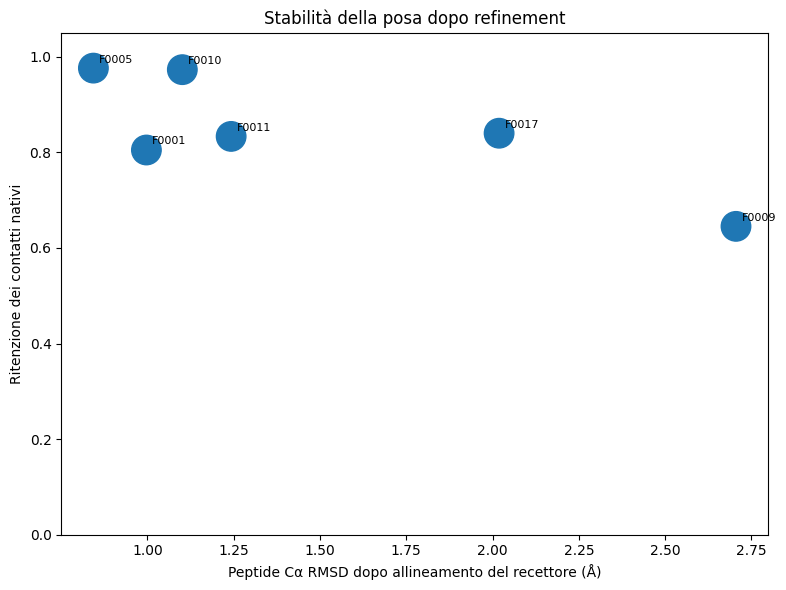

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(
    analysis[
        "peptide_CA_RMSD_after_receptor_alignment_A"
    ],
    analysis["native_contact_recall"],
    s=100 + 350 * analysis["hotspot_contact_preservation"].fillna(0),
)

for row in analysis.itertuples(index=False):
    plt.annotate(
        row.fragment_id,
        (
            row.peptide_CA_RMSD_after_receptor_alignment_A,
            row.native_contact_recall,
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("Peptide Cα RMSD dopo allineamento del recettore (Å)")
plt.ylabel("Ritenzione dei contatti nativi")
plt.title("Stabilità della posa dopo refinement")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    DOCKING_DIR / "peptide_rmsd_vs_native_contact_recall.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 20. Candidati raccomandati dopo il docking guidato


In [21]:
recommended_after_docking = analysis[
    analysis["recommended_after_guided_docking"]
].copy()

display(
    recommended_after_docking[
        [
            column
            for column in [
                "guided_docking_rank",
                "fragment_id",
                "sequence",
                "length",
                rosetta_score_column,
                "native_contact_recall",
                "hotspot_contact_preservation",
                "peptide_CA_RMSD_after_receptor_alignment_A",
                "guided_docking_combined_score",
                "best_pose_pdb_aligned",
            ]
            if column is not None
            and column in recommended_after_docking.columns
        ]
    ]
)

,guided_docking_rank,fragment_id,sequence,length,reweighted_sc,native_contact_recall,hotspot_contact_preservation,peptide_CA_RMSD_after_receptor_alignment_A,guided_docking_combined_score,best_pose_pdb_aligned
0,1,F0005,GYIGERCQYRDLKWW,15,25.660,0.976190,1.0,0.843274,0.816000,outputs/short_peptide_guided_docking_03c/best_poses/F0005_best_aligned_to_native_receptor.pdb
1,2,F0010,IGERCQYRDLK,11,29.918,0.972973,1.0,1.100980,0.750697,outputs/short_peptide_guided_docking_03c/best_poses/F0010_best_aligned_to_native_receptor.pdb
2,3,F0001,YIGERCQYRDLKW,13,75.599,0.804878,1.0,0.996883,0.572312,outputs/short_peptide_guided_docking_03c/best_poses/F0001_best_aligned_to_native_receptor.pdb


## 21. Esportazione


In [22]:
PANEL_CSV = DOCKING_DIR / "docking_fragment_panel.csv"
INPUT_VALIDATION_CSV = DOCKING_DIR / "input_complex_validation.csv"
NATIVE_METRICS_CSV = DOCKING_DIR / "native_input_metrics.csv"
ROSETTA_INPUTS_CSV = DOCKING_DIR / "rosetta_input_manifest.csv"
ROSETTA_STATUS_CSV = DOCKING_DIR / "rosetta_output_status.csv"
ROSETTA_ALL_SCORES_CSV = DOCKING_DIR / "rosetta_all_scores.csv"
ROSETTA_BEST_CSV = DOCKING_DIR / "rosetta_best_pose_per_fragment.csv"
POSE_EVALUATION_CSV = DOCKING_DIR / "best_pose_structural_evaluation.csv"
HOTSPOT_CONTACT_CSV = DOCKING_DIR / "hotspot_contact_preservation.csv"
FINAL_RANKING_CSV = DOCKING_DIR / "guided_docking_final_ranking.csv"
RECOMMENDED_CSV = DOCKING_DIR / "recommended_after_guided_docking.csv"
METADATA_JSON = DOCKING_DIR / "guided_docking_metadata.json"

docking_panel.to_csv(PANEL_CSV, index=False)
input_validation.to_csv(INPUT_VALIDATION_CSV, index=False)
native_metrics_df.to_csv(NATIVE_METRICS_CSV, index=False)
rosetta_inputs.to_csv(ROSETTA_INPUTS_CSV, index=False)
rosetta_output_status.to_csv(ROSETTA_STATUS_CSV, index=False)

if not rosetta_scores.empty:
    rosetta_scores.to_csv(
        ROSETTA_ALL_SCORES_CSV,
        index=False,
    )

if not best_rosetta_poses.empty:
    best_rosetta_poses.to_csv(
        ROSETTA_BEST_CSV,
        index=False,
    )

pose_evaluation.to_csv(
    POSE_EVALUATION_CSV,
    index=False,
)
hotspot_contact_metrics.to_csv(
    HOTSPOT_CONTACT_CSV,
    index=False,
)
analysis.to_csv(
    FINAL_RANKING_CSV,
    index=False,
)
recommended_after_docking.to_csv(
    RECOMMENDED_CSV,
    index=False,
)

metadata = {
    "receptor_chain": RECEPTOR_CHAIN,
    "peptide_chain": PEPTIDE_CHAIN,
    "contact_cutoff_A": CONTACT_CUTOFF_A,
    "clash_cutoff_A": CLASH_CUTOFF_A,
    "n_fragments": int(len(docking_panel)),
    "fragments": docking_panel[
        ["fragment_id", "sequence", "length"]
    ].to_dict(orient="records"),
    "rosetta_executable": rosetta_bin,
    "rosetta_database": (
        str(rosetta_db)
        if rosetta_db is not None
        else None
    ),
    "rosetta_nstruct": int(ROSETTA_NSTRUCT),
    "rosetta_executed": bool(
        rosetta_execution["executed"]
    ),
    "rosetta_returncode": (
        rosetta_execution["returncode"]
    ),
    "interpretation_warning": (
        "FlexPepDock refinement starts from a near-native pose. "
        "The ranking does not demonstrate blind docking success, "
        "experimental affinity, autonomous peptide folding, "
        "or inhibitory activity."
    ),
}

METADATA_JSON.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

for path in [
    PANEL_CSV,
    INPUT_VALIDATION_CSV,
    NATIVE_METRICS_CSV,
    ROSETTA_INPUTS_CSV,
    ROSETTA_STATUS_CSV,
    POSE_EVALUATION_CSV,
    HOTSPOT_CONTACT_CSV,
    FINAL_RANKING_CSV,
    RECOMMENDED_CSV,
    METADATA_JSON,
    rosetta_script,
]:
    print("Salvato:", path.resolve())

print("Migliori pose allineate:", BEST_POSE_DIR.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/docking_fragment_panel.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/input_complex_validation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/native_input_metrics.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_input_manifest.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_output_status.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/best_pose_structural_evaluation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/hotspot_contact_preservation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/guided_docking_final_ranking.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_do

## 22. Report automatico


In [23]:
if analysis.empty:
    report = '''# 03c Guided docking report

Nessuna posa Rosetta è stata analizzata.

Verificare:
- installazione di Rosetta;
- percorso del database;
- log di FlexPepDock;
- file di score e PDB nelle cartelle di output.
'''
else:
    best = analysis.iloc[0]

    report = f'''# 03c — Short-peptide guided docking report

## Pannello analizzato
- Frammenti: {len(analysis)}
- Recettore: catena {RECEPTOR_CHAIN}
- Peptide: catena {PEPTIDE_CHAIN}
- FlexPepDock nstruct: {ROSETTA_NSTRUCT}
- Contact cutoff: {CONTACT_CUTOFF_A:.1f} Å
- Clash cutoff: {CLASH_CUTOFF_A:.1f} Å

## Miglior frammento nel ranking guidato
- Fragment ID: {best["fragment_id"]}
- Sequenza: `{best["sequence"]}`
- Lunghezza: {int(best["length"])} aa
- Combined score: {best["guided_docking_combined_score"]:.4f}
- Native-contact recall: {best["native_contact_recall"]:.4f}
- Hotspot-contact preservation: {best["hotspot_contact_preservation"]:.4f}
- Peptide Cα RMSD: {best["peptide_CA_RMSD_after_receptor_alignment_A"]:.4f} Å
- Clash atomici sotto 2 Å: {int(best["pose_atom_clashes_lt_2A"])}

## Interpretazione
Il ranking privilegia frammenti che, dopo FlexPepDock refinement, mantengono la posa cristallografica, conservano i contatti nativi e degli hotspot e non introducono clash severi.

Il protocollo è guidato da una posa iniziale vicina a quella nativa. I risultati identificano candidati per ulteriori simulazioni e ottimizzazione, non binder confermati.
'''

REPORT_PATH = DOCKING_DIR / "03c_guided_docking_report.md"
REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("Report salvato:", REPORT_PATH.resolve())

# 03c — Short-peptide guided docking report

## Pannello analizzato
- Frammenti: 6
- Recettore: catena B
- Peptide: catena D
- FlexPepDock nstruct: 2
- Contact cutoff: 4.5 Å
- Clash cutoff: 2.0 Å

## Miglior frammento nel ranking guidato
- Fragment ID: F0005
- Sequenza: `GYIGERCQYRDLKWW`
- Lunghezza: 15 aa
- Combined score: 0.8160
- Native-contact recall: 0.9762
- Hotspot-contact preservation: 1.0000
- Peptide Cα RMSD: 0.8433 Å
- Clash atomici sotto 2 Å: 0

## Interpretazione
Il ranking privilegia frammenti che, dopo FlexPepDock refinement, mantengono la posa cristallografica, conservano i contatti nativi e degli hotspot e non introducono clash severi.

Il protocollo è guidato da una posa iniziale vicina a quella nativa. I risultati identificano candidati per ulteriori simulazioni e ottimizzazione, non binder confermati.

Report salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/03c_guided_docking_report.md


## 23. Interpretazione e passaggio successivo

### Il 03c può mostrare

- se un frammento rimane vicino alla posa nativa dopo refinement;
- se conserva i contatti principali con la catena B;
- se gli hotspot rimangono coinvolti nell'interfaccia;
- se compaiono clash;
- quale frammento offre il miglior compromesso tra miniaturizzazione e stabilità della posa.

### Il 03c non può ancora dimostrare

- folding autonomo del peptide in soluzione;
- associazione spontanea da una posa lontana;
- affinità sperimentale;
- attività inibitoria;
- stabilità su tempi molecolari lunghi.

### Passaggio successivo consigliato

Dopo l'esecuzione, i migliori 2–3 frammenti potranno essere portati a:

1. incremento di `ROSETTA_NSTRUCT`;
2. docking più esteso o perturbato;
3. dinamica molecolare;
4. generazione di varianti mirate;
5. applicazione di diffusione o CLEAR.
